<b>Heart Disease Prediction</b>

<i>This project focuses on predicting the presence of heart disease in a patient based on several clinical factors.

The dataset was imported from Kaggle.

Multiple classification models were made in order to find the best one.

Dataset link: https://www.kaggle.com/datasets/fedesoriano/heart-failure-prediction
</i>

1.<u>Data preprocessing</u>

<i>Importing modules</i>

- Imported neccessary modules

In [39]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

<i>Importing dataset</i>

- Imported dataset

In [2]:
dataset=pd.read_csv("heart.csv")

<i>Information about the dataset</i>

- Got some information about the dataset

In [3]:
dataset.info()

<class 'pandas.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    str    
 2   ChestPainType   918 non-null    str    
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    str    
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    str    
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    str    
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), str(5)
memory usage: 86.2 KB


<i>First 5 rows</i>

- Head of the dataset

In [4]:
dataset.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


<i>Last 5 rows</i>

- Tail of the dataset

In [64]:
dataset.tail()
dataset.head()

,Age,Sex,RestingBP,Cholesterol,FastingBS,MaxHR,ExerciseAngina,Oldpeak,HeartDisease,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ST_Slope_Flat,ST_Slope_Up
0,40,1,140,289,0,172,0,0.0,0,True,False,False,True,False,False,True
1,49,0,160,180,0,156,0,1.0,1,False,True,False,True,False,True,False
2,37,1,130,283,0,98,0,0.0,0,True,False,False,False,True,False,True
3,48,0,138,214,0,108,1,1.5,1,False,False,False,True,False,True,False
4,54,1,150,195,0,122,0,0.0,0,False,True,False,True,False,False,True


<i>Understanding the target variable</i>

- Checked the balance of the target class (HeartDisease)

Class balance for HeartDisease:
HeartDisease
1    508
0    410
Name: count, dtype: int64

HeartDisease
1    55.337691
0    44.662309
Name: proportion, dtype: float64


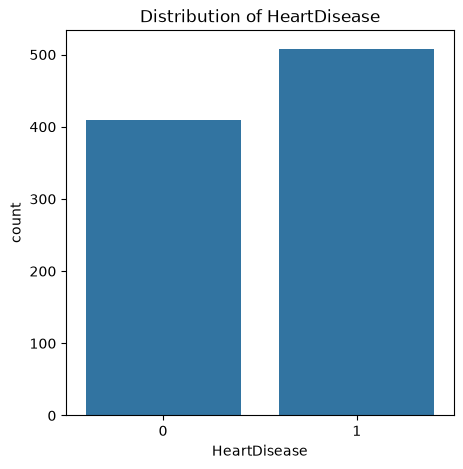

In [6]:
print("Class balance for HeartDisease:")
print(dataset["HeartDisease"].value_counts())
print()
print(dataset["HeartDisease"].value_counts(normalize=True)*100)

plt.figure(figsize=(5,5))
sns.countplot(x="HeartDisease",data=dataset)
plt.title("Distribution of HeartDisease")
plt.show()

<i>Understanding missing values</i>

- Checked if there were any missing values.

In [7]:
print("Number of missing values:")
print(dataset.isnull().sum())

Number of missing values:
Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64


<i>Understanding outliers</i>

- Checked if there were any outliers. Although outliers could be important as they represent real clinical events

In [8]:
numeric_col=dataset.select_dtypes(["int64","float64"]).drop("HeartDisease",axis="columns").columns

for col in numeric_col:
    q1=dataset[col].quantile(0.25)
    q3=dataset[col].quantile(0.75)
    iqr=q3-q1
    lower=q1-1.5*iqr
    upper=q3+1.5*iqr
    outliers=((dataset[col]<lower)|(dataset[col]>upper))
    print(f"The number of outliers in {col}: {outliers.sum()}")

The number of outliers in Age: 0
The number of outliers in RestingBP: 28
The number of outliers in Cholesterol: 183
The number of outliers in FastingBS: 214
The number of outliers in MaxHR: 2
The number of outliers in Oldpeak: 16


- Box plot

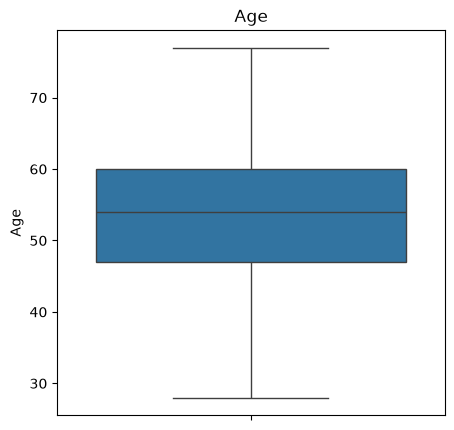

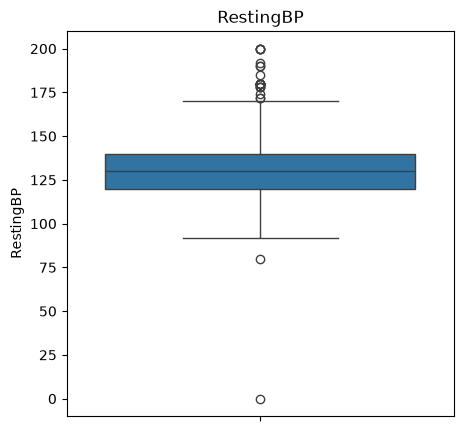

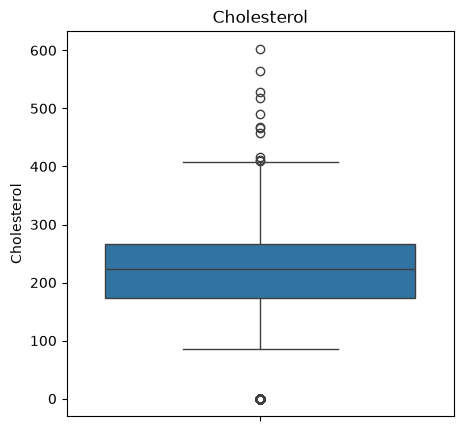

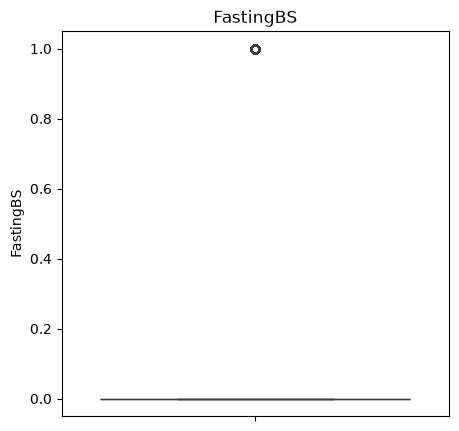

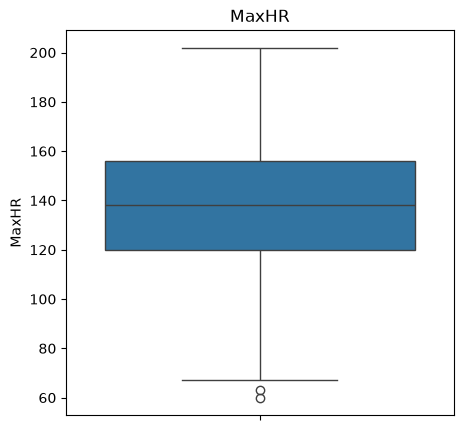

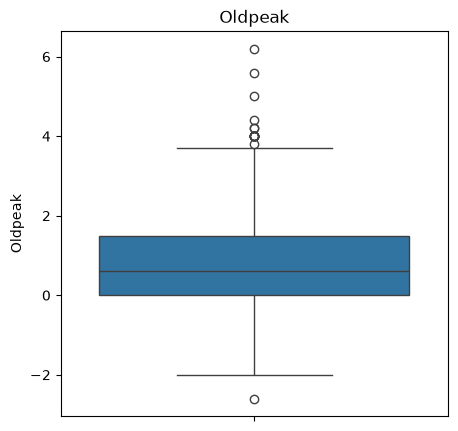

In [9]:
for col in numeric_col:
    plt.figure(figsize=(5,5))
    sns.boxplot(dataset[col])
    plt.title(col)
    plt.show()

<i>Understanding normal distribution of data</i>

- Cholesterol has some zero values that skew the distribution, and Oldpeak is right-skewed

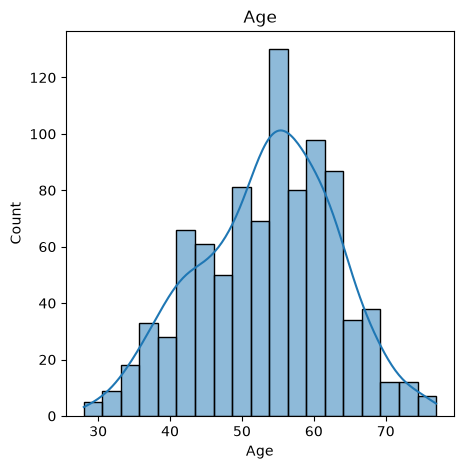

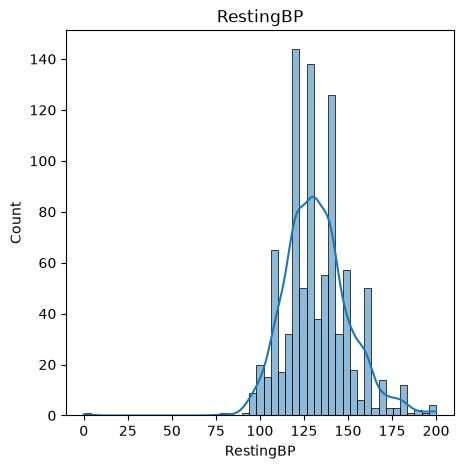

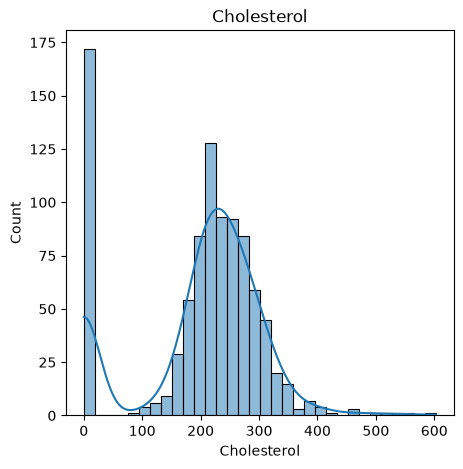

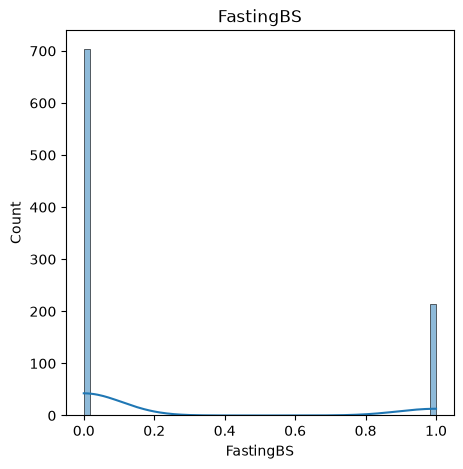

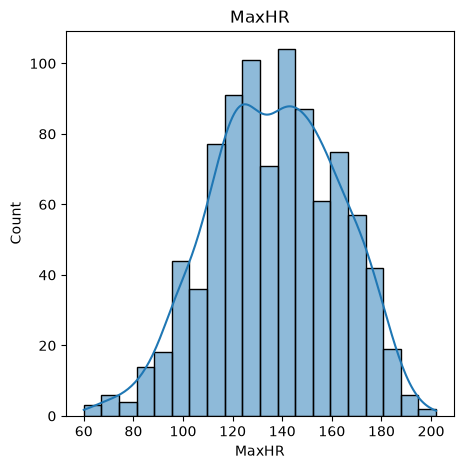

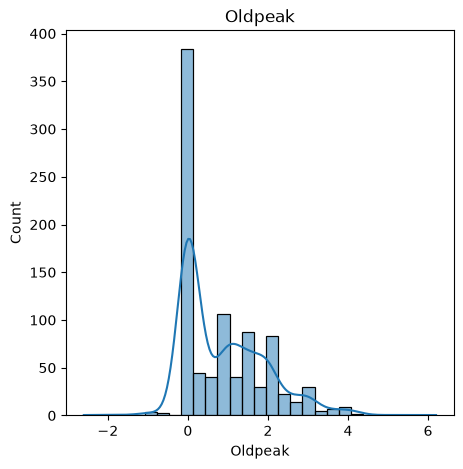

In [10]:
for col in numeric_col:
    plt.figure(figsize=(5,5))
    sns.histplot(dataset[col],kde=True)
    plt.title(col)
    plt.show()

<i>Understanding categorical columns</i>

- Checked the unique categories present in every categorical column

In [11]:
categorical_col=dataset.select_dtypes(["object","string"]).columns

for col in categorical_col:
    print(f"Unique values in {col}: {dataset[col].unique()}")

Unique values in Sex: <StringArray>
['M', 'F']
Length: 2, dtype: str
Unique values in ChestPainType: <StringArray>
['ATA', 'NAP', 'ASY', 'TA']
Length: 4, dtype: str
Unique values in RestingECG: <StringArray>
['Normal', 'ST', 'LVH']
Length: 3, dtype: str
Unique values in ExerciseAngina: <StringArray>
['N', 'Y']
Length: 2, dtype: str
Unique values in ST_Slope: <StringArray>
['Up', 'Flat', 'Down']
Length: 3, dtype: str


- Count plot for every categorical column against the target

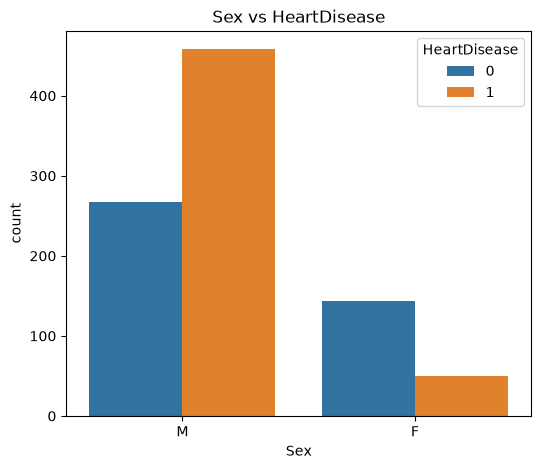

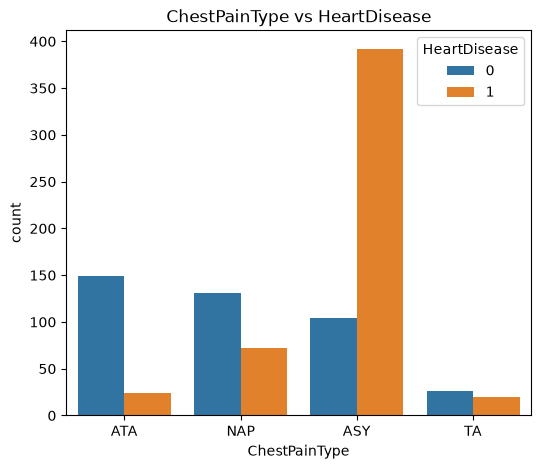

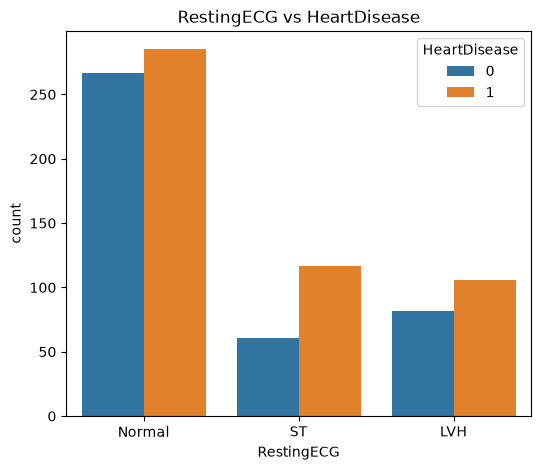

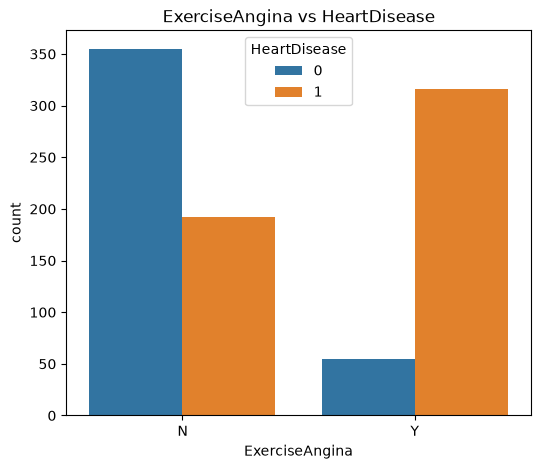

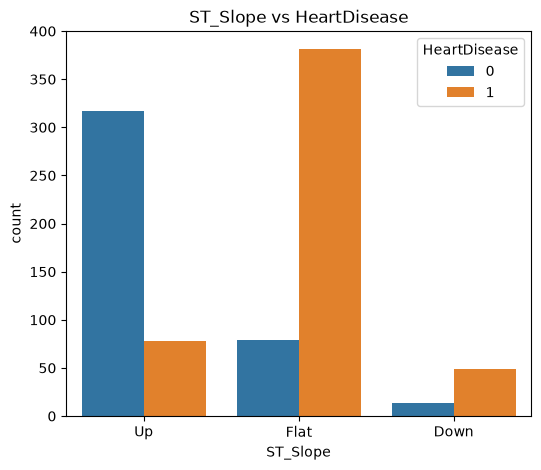

In [12]:
for col in categorical_col:
    plt.figure(figsize=(6,5))
    sns.countplot(x=col,hue="HeartDisease",data=dataset)
    plt.title(f"{col} vs HeartDisease")
    plt.show()

<i>Encoding categorical columns</i>

- Label encoded the binary categorical columns (Sex, ExerciseAngina) and one-hot encoded the remaining ones (ChestPainType, RestingECG, ST_Slope)

In [13]:
from sklearn.preprocessing import LabelEncoder

label_enc=LabelEncoder()
dataset["Sex"]=label_enc.fit_transform(dataset["Sex"])
dataset["ExerciseAngina"]=label_enc.fit_transform(dataset["ExerciseAngina"])

dataset=pd.get_dummies(dataset,columns=["ChestPainType","RestingECG","ST_Slope"],drop_first=True)

- Updated dataset

In [14]:
dataset

,Age,Sex,RestingBP,Cholesterol,FastingBS,MaxHR,ExerciseAngina,Oldpeak,HeartDisease,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ST_Slope_Flat,ST_Slope_Up
0,40,1,140,289,0,172,0,0.0,0,True,False,False,True,False,False,True
1,49,0,160,180,0,156,0,1.0,1,False,True,False,True,False,True,False
2,37,1,130,283,0,98,0,0.0,0,True,False,False,False,True,False,True
3,48,0,138,214,0,108,1,1.5,1,False,False,False,True,False,True,False
4,54,1,150,195,0,122,0,0.0,0,False,True,False,True,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,1,110,264,0,132,0,1.2,1,False,False,True,True,False,True,False
914,68,1,144,193,1,141,0,3.4,1,False,False,False,True,False,True,False
915,57,1,130,131,0,115,1,1.2,1,False,False,False,True,False,True,False
916,57,0,130,236,0,174,0,0.0,1,True,False,False,False,False,True,False


<i>Dropping unnecessary columns using the ANOVA result</i>

- Dropped unnecessary columns based on if p-values > 0.05 (i.e. the feature does not differ significantly between the two HeartDisease groups)

In [15]:
from sklearn.feature_selection import f_classif

X_anova=dataset.drop("HeartDisease",axis="columns")
y_anova=dataset["HeartDisease"]

f_values,p_values=f_classif(X_anova,y_anova)

for col,p in zip(X_anova.columns,p_values):
    print(f"For {col}, the ANOVA p-value is: {p:.4f}")

For Age, the ANOVA p-value is: 0.0000
For Sex, the ANOVA p-value is: 0.0000
For RestingBP, the ANOVA p-value is: 0.0011
For Cholesterol, the ANOVA p-value is: 0.0000
For FastingBS, the ANOVA p-value is: 0.0000
For MaxHR, the ANOVA p-value is: 0.0000
For ExerciseAngina, the ANOVA p-value is: 0.0000
For Oldpeak, the ANOVA p-value is: 0.0000
For ChestPainType_ATA, the ANOVA p-value is: 0.0000
For ChestPainType_NAP, the ANOVA p-value is: 0.0000
For ChestPainType_TA, the ANOVA p-value is: 0.0971
For RestingECG_Normal, the ANOVA p-value is: 0.0055
For RestingECG_ST, the ANOVA p-value is: 0.0019
For ST_Slope_Flat, the ANOVA p-value is: 0.0000
For ST_Slope_Up, the ANOVA p-value is: 0.0000


In [ ]:
# All columns turned out to be significant (p<0.05), so none were dropped
dataset

<i>Heatmap</i>

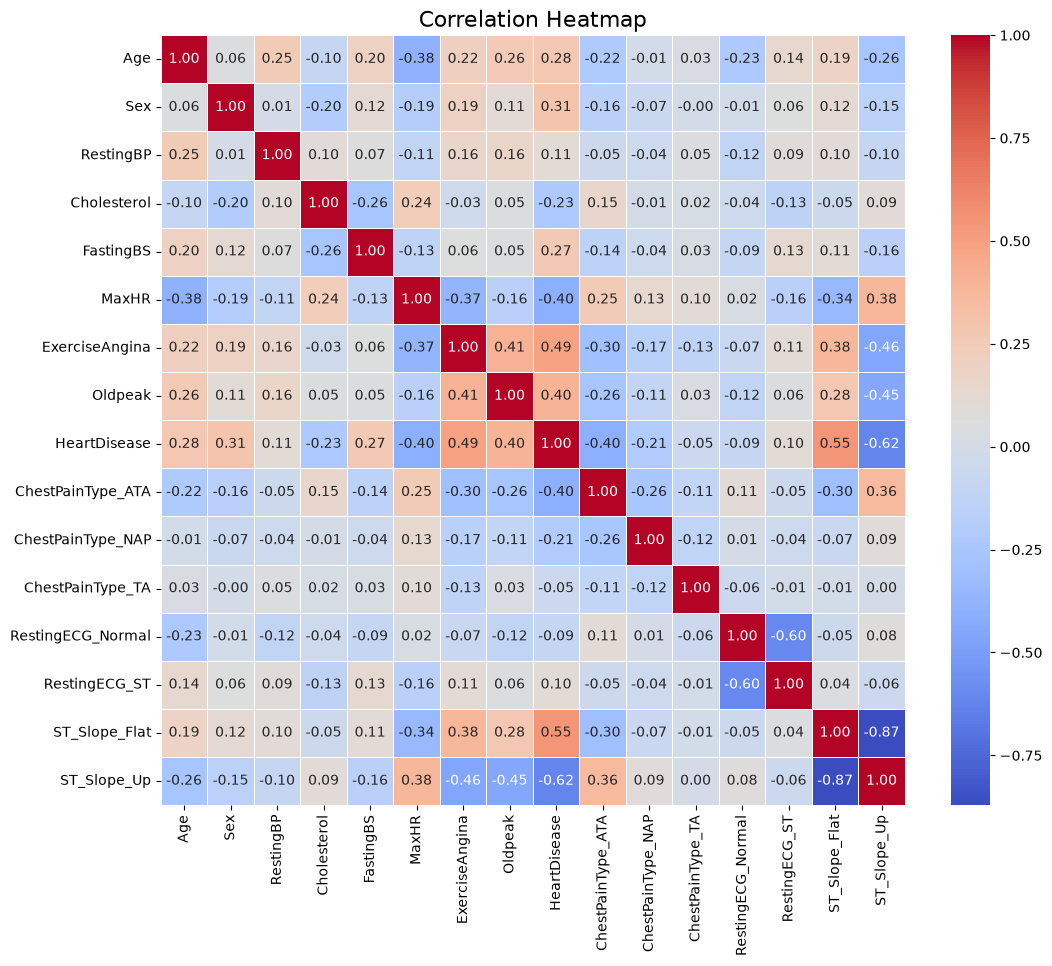

In [16]:
plt.figure(figsize=(12, 10))

sns.heatmap(
    dataset.corr(numeric_only=True),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Heatmap", fontsize=16)
plt.show()

<i>Splitting the dataset into Matrix of Features (X) and Dependent Variable Vector (y)</i>

In [17]:
X=dataset.drop("HeartDisease",axis="columns").values
y=dataset["HeartDisease"].values

<i>Splitting the dataset into training and test set</i>

In [18]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=0,stratify=y)

<i>Feature scaling</i>

- Used standard scaler because of columns like Age, RestingBP and Cholesterol being on very different scales

In [19]:
from sklearn.preprocessing import StandardScaler

scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

2.<u>Model building</u>

<b>a. Logistic Regression</b>

<i>Model building</i>

In [20]:
from sklearn.linear_model import LogisticRegression

classifier1=LogisticRegression(random_state=0)
classifier1.fit(X_train,y_train)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",0
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver

<i>Predicting the values for the training and the test set</i>

In [21]:
y_pred_train=classifier1.predict(X_train)
y_pred_test=classifier1.predict(X_test)

print("For the training set:")
print("[Actual_Values Predicted_Values]")
print(np.concatenate((y_train.reshape(len(y_train),1),y_pred_train.reshape(len(y_pred_train),1)),axis=1)[:10])
print()

print("For the test set:")
print("[Actual_Values Predicted_Values]")
print(np.concatenate((y_test.reshape(len(y_test),1),y_pred_test.reshape(len(y_pred_test),1)),axis=1)[:10])

For the training set:
[Actual_Values Predicted_Values]
[[0 0]
 [0 0]
 [1 1]
 [1 1]
 [1 1]
 [1 1]
 [1 0]
 [1 1]
 [0 0]
 [1 1]]

For the test set:
[Actual_Values Predicted_Values]
[[1 1]
 [1 1]
 [0 0]
 [1 1]
 [1 1]
 [0 0]
 [0 1]
 [1 1]
 [0 0]
 [1 0]]


<i>Graphical Representation</i>

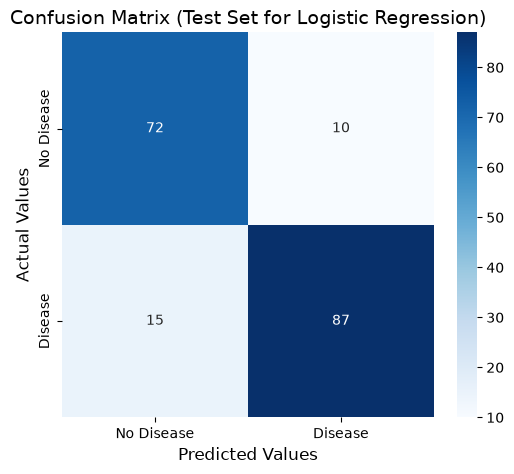

In [22]:
from sklearn.metrics import confusion_matrix

cm=confusion_matrix(y_test,y_pred_test)

plt.figure(figsize=(6, 5))
sns.heatmap(cm,annot=True,fmt="d",cmap="Blues",
            xticklabels=["No Disease","Disease"],yticklabels=["No Disease","Disease"])
plt.title("Confusion Matrix (Test Set for Logistic Regression)", fontsize=14)
plt.xlabel("Predicted Values", fontsize=12)
plt.ylabel("Actual Values", fontsize=12)
plt.show()

<i>Accuracy of the model</i>

In [23]:
from sklearn.metrics import accuracy_score

print(f"Accuracy for the training set is: {accuracy_score(y_train,y_pred_train)*100:.2f}%")

print(f"Accuracy for the test set is: {accuracy_score(y_test,y_pred_test)*100:.2f}%")

Accuracy for the training set is: 87.06%
Accuracy for the test set is: 86.41%


<i>Error in the model</i>

In [24]:
from sklearn.metrics import precision_score, recall_score, f1_score, classification_report

precision_test=precision_score(y_test,y_pred_test)
recall_test=recall_score(y_test,y_pred_test)
f1_test=f1_score(y_test,y_pred_test)

print("For test set:")
print(f"Precision: {precision_test:.2f}")
print(f"Recall: {recall_test:.2f}")
print(f"F1-Score: {f1_test:.2f}")
print()
print("Classification Report:")
print(classification_report(y_test,y_pred_test,target_names=["No Disease","Disease"]))

For test set:
Precision: 0.90
Recall: 0.85
F1-Score: 0.87

Classification Report:
              precision    recall  f1-score   support

  No Disease       0.83      0.88      0.85        82
     Disease       0.90      0.85      0.87       102

    accuracy                           0.86       184
   macro avg       0.86      0.87      0.86       184
weighted avg       0.87      0.86      0.86       184



<i>Cross-Validation</i>

In [25]:
from sklearn.model_selection import cross_val_score

cv=cross_val_score(classifier1,X_train,y_train,cv=10)

print(f"Training accuracy after cross-validation is: {cv.mean()*100:.2f}%")

Training accuracy after cross-validation is: 86.11%


<b>b. K-Nearest Neighbors</b>

<i>Finding best number of neighbors</i>

In [26]:
from sklearn.neighbors import KNeighborsClassifier
import pprint

dic={}
for i in range(1,21):
    dummy=KNeighborsClassifier(n_neighbors=i)
    dummy.fit(X_train,y_train)
    
    y_pred_train_dummy=dummy.predict(X_train)
    y_pred_test_dummy=dummy.predict(X_test)
    
    acc_train_dummy=accuracy_score(y_train,y_pred_train_dummy)
    acc_test_dummy=accuracy_score(y_test,y_pred_test_dummy)
    
    dic[i]=[f"Training Accuracy: {acc_train_dummy:.2f}, Test Accuracy: {acc_test_dummy:.2f}"]
    
pprint.pprint(dic)

{1: ['Training Accuracy: 1.00, Test Accuracy: 0.82'],
 2: ['Training Accuracy: 0.90, Test Accuracy: 0.79'],
 3: ['Training Accuracy: 0.92, Test Accuracy: 0.86'],
 4: ['Training Accuracy: 0.90, Test Accuracy: 0.84'],
 5: ['Training Accuracy: 0.90, Test Accuracy: 0.89'],
 6: ['Training Accuracy: 0.89, Test Accuracy: 0.88'],
 7: ['Training Accuracy: 0.89, Test Accuracy: 0.87'],
 8: ['Training Accuracy: 0.89, Test Accuracy: 0.86'],
 9: ['Training Accuracy: 0.89, Test Accuracy: 0.85'],
 10: ['Training Accuracy: 0.89, Test Accuracy: 0.86'],
 11: ['Training Accuracy: 0.88, Test Accuracy: 0.88'],
 12: ['Training Accuracy: 0.88, Test Accuracy: 0.86'],
 13: ['Training Accuracy: 0.89, Test Accuracy: 0.87'],
 14: ['Training Accuracy: 0.87, Test Accuracy: 0.87'],
 15: ['Training Accuracy: 0.88, Test Accuracy: 0.88'],
 16: ['Training Accuracy: 0.88, Test Accuracy: 0.88'],
 17: ['Training Accuracy: 0.88, Test Accuracy: 0.89'],
 18: ['Training Accuracy: 0.89, Test Accuracy: 0.88'],
 19: ['Training Acc

<i>Model building</i>

- We choose n_neighbors=3, since it gives one of the highest test accuracies without the training accuracy running away from it (larger values overfit the training set)

In [27]:
from sklearn.neighbors import KNeighborsClassifier

classifier2=KNeighborsClassifier(n_neighbors=3)
classifier2.fit(X_train,y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",3
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",None
Name,Type,Value
"classes_ classes_: array of shape (n_classes,)Class labels known to the classifier","ndarray[int64](2,)","[0,1]"
"effective_metric_ effective_metric_: str or callbleThe distance metric used. It will be same as the `metric` parameteror a synonym of it, e.g. 'euclidean' if the `metric` parameter set to'minkowski' and `p` parameter set to 2.",str,'eu...an'


<i>Predicting the values for the training and the test set</i>

In [28]:
y_pred_train2=classifier2.predict(X_train)
y_pred_test2=classifier2.predict(X_test)

print("For the training set:")
print("[Actual_Values Predicted_Values]")
print(np.concatenate((y_train.reshape(len(y_train),1),y_pred_train2.reshape(len(y_pred_train2),1)),axis=1)[:10])
print()

print("For the test set:")
print("[Actual_Values Predicted_Values]")
print(np.concatenate((y_test.reshape(len(y_test),1),y_pred_test2.reshape(len(y_pred_test2),1)),axis=1)[:10])

For the training set:
[Actual_Values Predicted_Values]
[[0 0]
 [0 0]
 [1 1]
 [1 1]
 [1 1]
 [1 1]
 [1 0]
 [1 1]
 [0 0]
 [1 1]]

For the test set:
[Actual_Values Predicted_Values]
[[1 1]
 [1 1]
 [0 0]
 [1 1]
 [1 1]
 [0 0]
 [0 1]
 [1 1]
 [0 0]
 [1 0]]


<i>Graphical Representation</i>

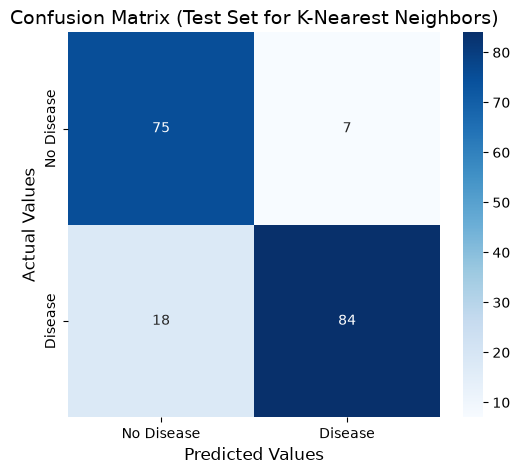

In [29]:
cm2=confusion_matrix(y_test,y_pred_test2)

plt.figure(figsize=(6, 5))
sns.heatmap(cm2,annot=True,fmt="d",cmap="Blues",
            xticklabels=["No Disease","Disease"],yticklabels=["No Disease","Disease"])
plt.title("Confusion Matrix (Test Set for K-Nearest Neighbors)", fontsize=14)
plt.xlabel("Predicted Values", fontsize=12)
plt.ylabel("Actual Values", fontsize=12)
plt.show()

<i>Accuracy of the model</i>

In [30]:
print(f"Accuracy for the training set is: {accuracy_score(y_train,y_pred_train2)*100:.2f}%")

print(f"Accuracy for the test set is: {accuracy_score(y_test,y_pred_test2)*100:.2f}%")

Accuracy for the training set is: 91.69%
Accuracy for the test set is: 86.41%


<i>Error of the model</i>

In [31]:
print("Classification Report:")
print(classification_report(y_test,y_pred_test2,target_names=["No Disease","Disease"]))

Classification Report:
              precision    recall  f1-score   support

  No Disease       0.81      0.91      0.86        82
     Disease       0.92      0.82      0.87       102

    accuracy                           0.86       184
   macro avg       0.86      0.87      0.86       184
weighted avg       0.87      0.86      0.86       184



<i>Cross-Validation</i>

In [32]:
from sklearn.model_selection import KFold

kf = KFold(n_splits=10, shuffle=True, random_state=0)
fold_scores = []

for train_idx, val_idx in kf.split(X_train):
    X_tr, X_val = X_train[train_idx], X_train[val_idx]
    y_tr, y_val = y_train[train_idx], y_train[val_idx]
    
    model = KNeighborsClassifier(n_neighbors=3)
    model.fit(X_tr, y_tr)
    
    score = accuracy_score(y_val, model.predict(X_val))
    fold_scores.append(score)

print(f"Mean CV Accuracy for n_neighbors=3: {np.mean(fold_scores)*100:.2f}%")

Mean CV Accuracy for n_neighbors=3: 86.38%


<b>c. Support Vector Classification</b>

<i>Model building</i>

In [40]:
from sklearn.svm import SVC

classifier3=SVC(kernel="rbf",probability=True,random_state=0)
classifier3.fit(X_train,y_train)

,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide <scores_probabilities>`...deprecated:: 1.9 The `probability` parameter is deprecated and will be removed in 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`.",True
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo random number generation for shuffling the data forprobability estimates. Ignored when `probability` is False.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",0
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide <shrinking_svm>`.",True
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None


<i>Predicting the values for the training and the test set</i>

In [41]:
y_pred_train3=classifier3.predict(X_train)
y_pred_test3=classifier3.predict(X_test)

print("For the training set:")
print("[Actual_Values Predicted_Values]")
print(np.concatenate((y_train.reshape(len(y_train),1),y_pred_train3.reshape(len(y_pred_train3),1)),axis=1)[:10])
print()

print("For the test set:")
print("[Actual_Values Predicted_Values]")
print(np.concatenate((y_test.reshape(len(y_test),1),y_pred_test3.reshape(len(y_pred_test3),1)),axis=1)[:10])

For the training set:
[Actual_Values Predicted_Values]
[[0 0]
 [0 0]
 [1 1]
 [1 1]
 [1 1]
 [1 1]
 [1 0]
 [1 1]
 [0 0]
 [1 1]]

For the test set:
[Actual_Values Predicted_Values]
[[1 1]
 [1 1]
 [0 0]
 [1 1]
 [1 1]
 [0 0]
 [0 0]
 [1 1]
 [0 0]
 [1 0]]


<i>Graphical Representation</i>

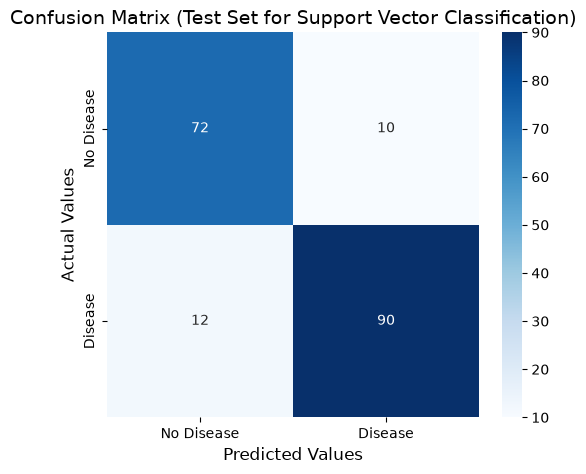

In [42]:
cm3=confusion_matrix(y_test,y_pred_test3)

plt.figure(figsize=(6, 5))
sns.heatmap(cm3,annot=True,fmt="d",cmap="Blues",
            xticklabels=["No Disease","Disease"],yticklabels=["No Disease","Disease"])
plt.title("Confusion Matrix (Test Set for Support Vector Classification)", fontsize=14)
plt.xlabel("Predicted Values", fontsize=12)
plt.ylabel("Actual Values", fontsize=12)
plt.show()

<i>Accuracy of the model</i>

In [43]:
print(f"Accuracy for the training set is: {accuracy_score(y_train,y_pred_train3)*100:.2f}%")

print(f"Accuracy for the test set is: {accuracy_score(y_test,y_pred_test3)*100:.2f}%")

Accuracy for the training set is: 91.28%
Accuracy for the test set is: 88.04%


<i>Error of the model</i>

In [44]:
print("Classification Report:")
print(classification_report(y_test,y_pred_test3,target_names=["No Disease","Disease"]))

Classification Report:
              precision    recall  f1-score   support

  No Disease       0.86      0.88      0.87        82
     Disease       0.90      0.88      0.89       102

    accuracy                           0.88       184
   macro avg       0.88      0.88      0.88       184
weighted avg       0.88      0.88      0.88       184



<i>Cross-Validation</i>

In [45]:
cv3=cross_val_score(classifier3,X_train,y_train,cv=10)

print(f"Training accuracy after cross-validation is: {cv3.mean()*100:.2f}%")

Training accuracy after cross-validation is: 86.78%


<b>d. Decision Tree Classification</b>

<i>Finding best max-depth</i>

In [46]:
from sklearn.tree import DecisionTreeClassifier

dic1={}
for i in range(1,11):
    dummy1=DecisionTreeClassifier(max_depth=i,random_state=0)
    dummy1.fit(X_train,y_train)
    
    y_pred_train_dummy1=dummy1.predict(X_train)
    y_pred_test_dummy1=dummy1.predict(X_test)
    
    acc_train_dummy1=accuracy_score(y_train,y_pred_train_dummy1)
    acc_test_dummy1=accuracy_score(y_test,y_pred_test_dummy1)
    
    dic1[i]=[f"Training Accuracy: {acc_train_dummy1:.2f}, Test Accuracy: {acc_test_dummy1:.2f}"]
    
pprint.pprint(dic1)

{1: ['Training Accuracy: 0.81, Test Accuracy: 0.82'],
 2: ['Training Accuracy: 0.84, Test Accuracy: 0.84'],
 3: ['Training Accuracy: 0.85, Test Accuracy: 0.85'],
 4: ['Training Accuracy: 0.88, Test Accuracy: 0.85'],
 5: ['Training Accuracy: 0.90, Test Accuracy: 0.85'],
 6: ['Training Accuracy: 0.92, Test Accuracy: 0.84'],
 7: ['Training Accuracy: 0.94, Test Accuracy: 0.83'],
 8: ['Training Accuracy: 0.95, Test Accuracy: 0.82'],
 9: ['Training Accuracy: 0.96, Test Accuracy: 0.79'],
 10: ['Training Accuracy: 0.97, Test Accuracy: 0.82']}


<i>Model building</i>

- We choose the max-depth that gives the highest test accuracy without overfitting the training set (see printed results above)

In [47]:
from sklearn.tree import DecisionTreeClassifier

classifier4=DecisionTreeClassifier(max_depth=4,random_state=0)
classifier4.fit(X_train,y_train)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",4
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",0
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at t

<i>Predicting the values for the training and the test set</i>

In [48]:
y_pred_train4=classifier4.predict(X_train)
y_pred_test4=classifier4.predict(X_test)

print("For the training set:")
print("[Actual_Values Predicted_Values]")
print(np.concatenate((y_train.reshape(len(y_train),1),y_pred_train4.reshape(len(y_pred_train4),1)),axis=1)[:10])
print()

print("For the test set:")
print("[Actual_Values Predicted_Values]")
print(np.concatenate((y_test.reshape(len(y_test),1),y_pred_test4.reshape(len(y_pred_test4),1)),axis=1)[:10])

For the training set:
[Actual_Values Predicted_Values]
[[0 0]
 [0 0]
 [1 1]
 [1 1]
 [1 1]
 [1 1]
 [1 0]
 [1 1]
 [0 0]
 [1 1]]

For the test set:
[Actual_Values Predicted_Values]
[[1 1]
 [1 1]
 [0 0]
 [1 1]
 [1 1]
 [0 0]
 [0 0]
 [1 1]
 [0 0]
 [1 0]]


<i>Graphical Representation</i>

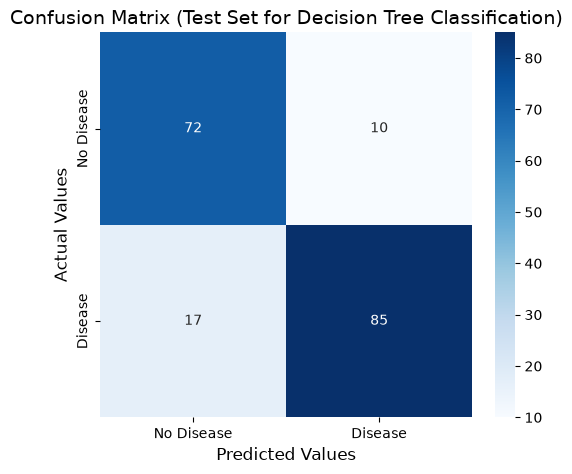

In [49]:
cm4=confusion_matrix(y_test,y_pred_test4)

plt.figure(figsize=(6, 5))
sns.heatmap(cm4,annot=True,fmt="d",cmap="Blues",
            xticklabels=["No Disease","Disease"],yticklabels=["No Disease","Disease"])
plt.title("Confusion Matrix (Test Set for Decision Tree Classification)", fontsize=14)
plt.xlabel("Predicted Values", fontsize=12)
plt.ylabel("Actual Values", fontsize=12)
plt.show()

<i>Accuracy of the model</i>

In [50]:
print(f"Accuracy for the training set is: {accuracy_score(y_train,y_pred_train4)*100:.2f}%")

print(f"Accuracy for the test set is: {accuracy_score(y_test,y_pred_test4)*100:.2f}%")

Accuracy for the training set is: 88.15%
Accuracy for the test set is: 85.33%


<i>Plotting decision tree</i>

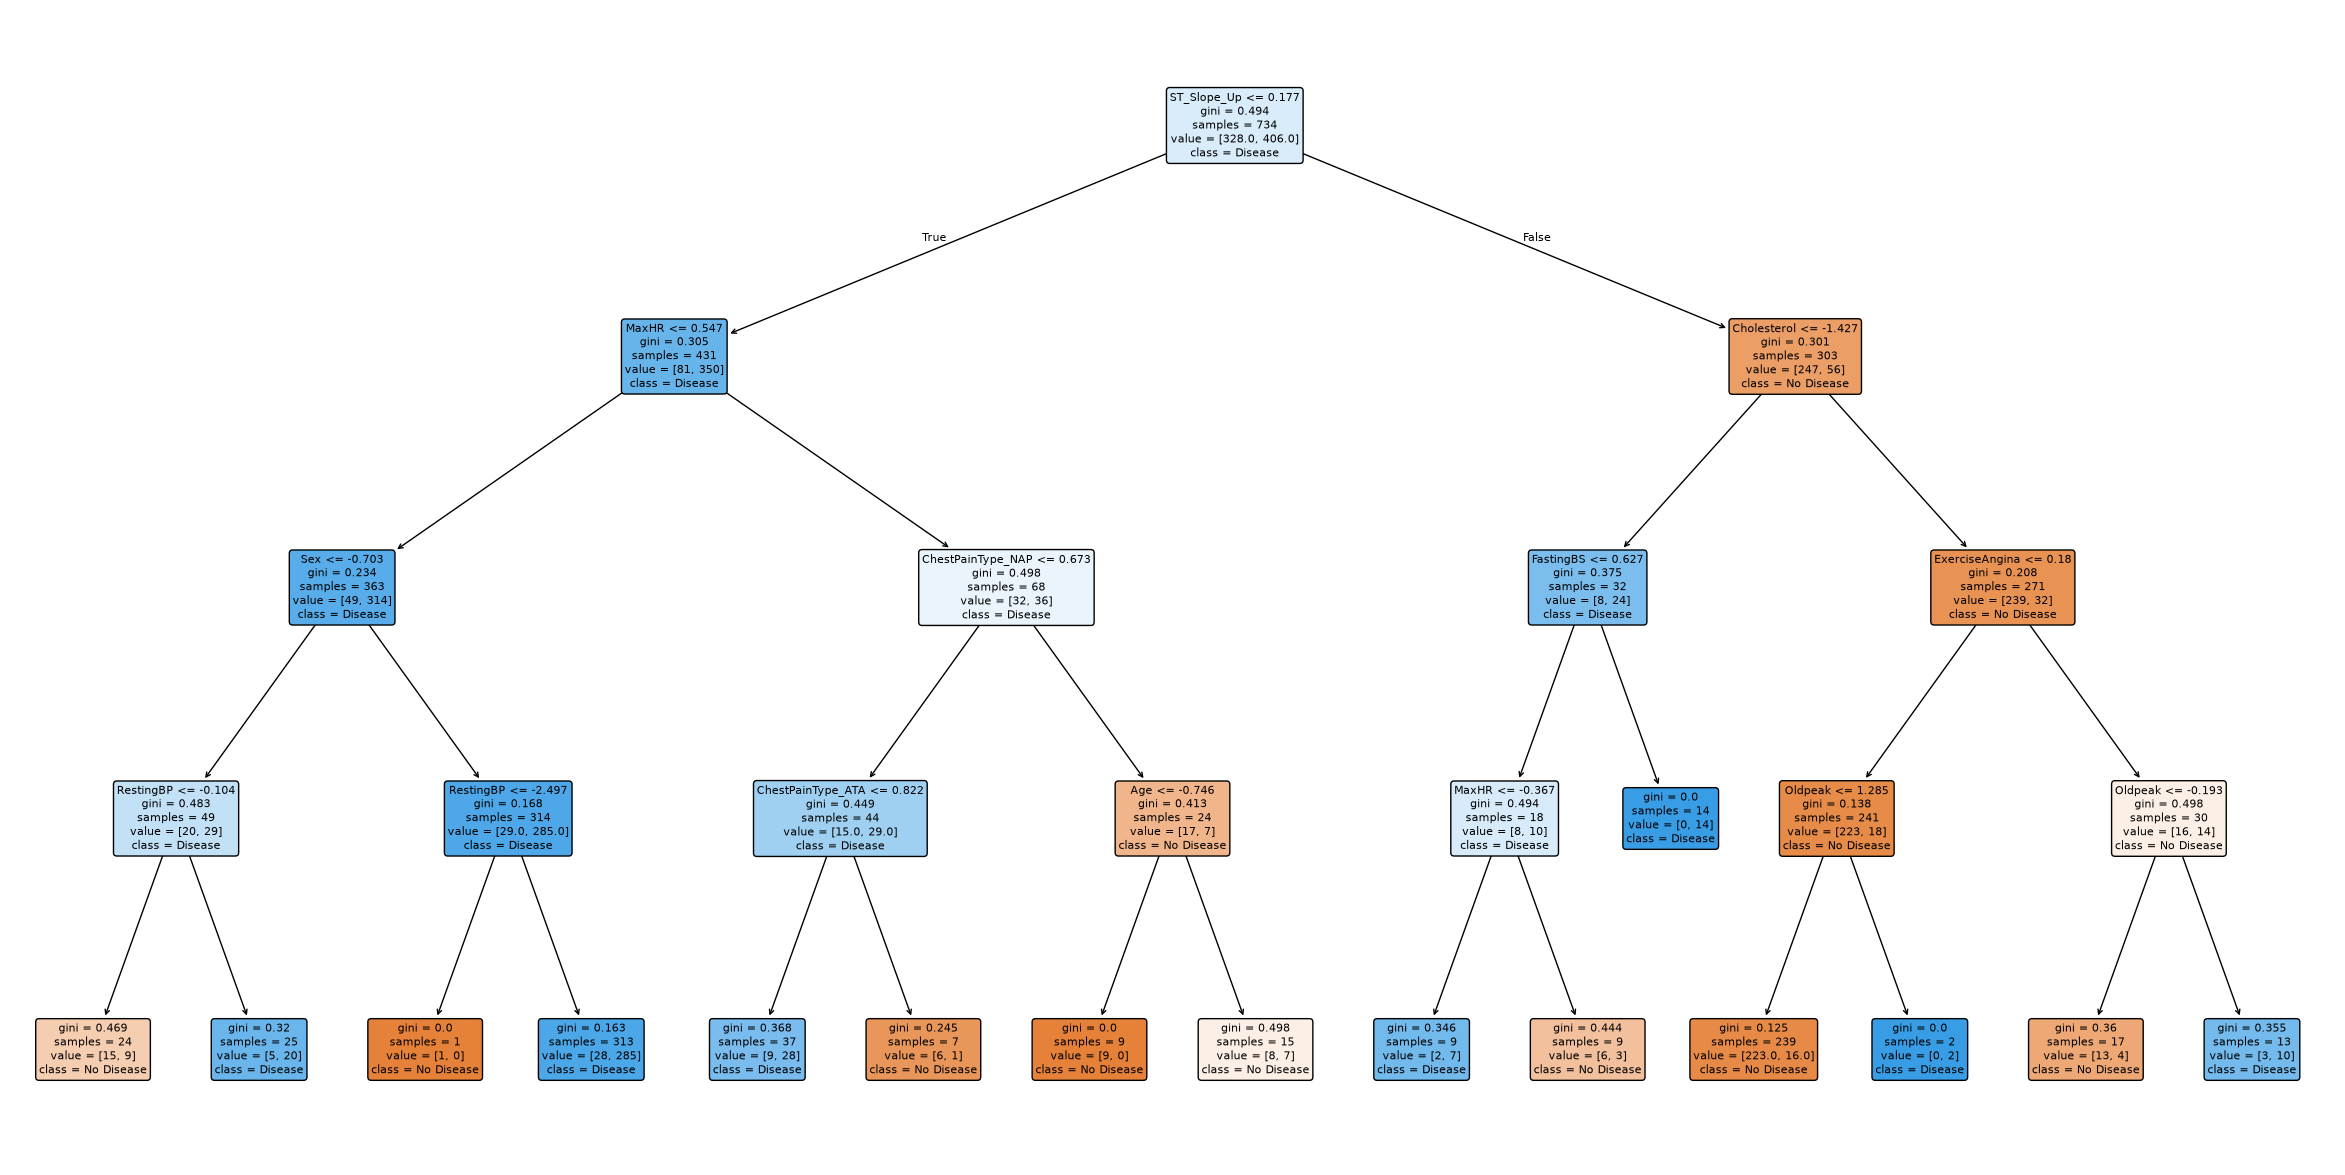

In [51]:
from sklearn.tree import plot_tree

feature_names=list(dataset.drop("HeartDisease",axis="columns").columns)

plt.figure(figsize=(30,15))
plot_tree(
    classifier4,
    feature_names=feature_names,
    class_names=["No Disease","Disease"],
    filled=True,
    rounded=True,
    fontsize=8
)

plt.show()

<i>Error of the model</i>

In [52]:
print("Classification Report:")
print(classification_report(y_test,y_pred_test4,target_names=["No Disease","Disease"]))

Classification Report:
              precision    recall  f1-score   support

  No Disease       0.81      0.88      0.84        82
     Disease       0.89      0.83      0.86       102

    accuracy                           0.85       184
   macro avg       0.85      0.86      0.85       184
weighted avg       0.86      0.85      0.85       184



<i>Cross-Validation</i>

In [53]:
cv4=cross_val_score(classifier4,X_train,y_train,cv=10)

print(f"Training accuracy after cross-validation is: {cv4.mean()*100:.2f}%")

Training accuracy after cross-validation is: 83.24%


<b>e. Random Forest Classification</b>

<i>Finding the best number of estimators</i>

In [54]:
from sklearn.ensemble import RandomForestClassifier

dic2={}
for i in range(100,1001,100):
    dummy2=RandomForestClassifier(n_estimators=i,random_state=0)
    dummy2.fit(X_train,y_train)
    
    y_pred_train_dummy2=dummy2.predict(X_train)
    y_pred_test_dummy2=dummy2.predict(X_test)
    
    acc_train_dummy2=accuracy_score(y_train,y_pred_train_dummy2)
    acc_test_dummy2=accuracy_score(y_test,y_pred_test_dummy2)
    
    dic2[i]=[f"Training Accuracy: {acc_train_dummy2:.2f}, Test Accuracy: {acc_test_dummy2:.2f}"]
    
pprint.pprint(dic2)

{100: ['Training Accuracy: 1.00, Test Accuracy: 0.88'],
 200: ['Training Accuracy: 1.00, Test Accuracy: 0.88'],
 300: ['Training Accuracy: 1.00, Test Accuracy: 0.87'],
 400: ['Training Accuracy: 1.00, Test Accuracy: 0.87'],
 500: ['Training Accuracy: 1.00, Test Accuracy: 0.86'],
 600: ['Training Accuracy: 1.00, Test Accuracy: 0.87'],
 700: ['Training Accuracy: 1.00, Test Accuracy: 0.87'],
 800: ['Training Accuracy: 1.00, Test Accuracy: 0.87'],
 900: ['Training Accuracy: 1.00, Test Accuracy: 0.87'],
 1000: ['Training Accuracy: 1.00, Test Accuracy: 0.87']}


<i>Model building</i>

- We choose the number of estimators as 100, as there aren't really any differences in the accuracies for higher values

In [55]:
from sklearn.ensemble import RandomForestClassifier

classifier5=RandomForestClassifier(n_estimators=100,random_state=0)
classifier5.fit(X_train,y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",0
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstra

<i>Predicting the values for the training and the test set</i>

In [56]:
y_pred_train5=classifier5.predict(X_train)
y_pred_test5=classifier5.predict(X_test)

print("For the training set:")
print("[Actual_Values Predicted_Values]")
print(np.concatenate((y_train.reshape(len(y_train),1),y_pred_train5.reshape(len(y_pred_train5),1)),axis=1)[:10])
print()

print("For the test set:")
print("[Actual_Values Predicted_Values]")
print(np.concatenate((y_test.reshape(len(y_test),1),y_pred_test5.reshape(len(y_pred_test5),1)),axis=1)[:10])

For the training set:
[Actual_Values Predicted_Values]
[[0 0]
 [0 0]
 [1 1]
 [1 1]
 [1 1]
 [1 1]
 [1 1]
 [1 1]
 [0 0]
 [1 1]]

For the test set:
[Actual_Values Predicted_Values]
[[1 1]
 [1 1]
 [0 0]
 [1 1]
 [1 1]
 [0 0]
 [0 0]
 [1 1]
 [0 0]
 [1 0]]


<i>Graphical Representation</i>

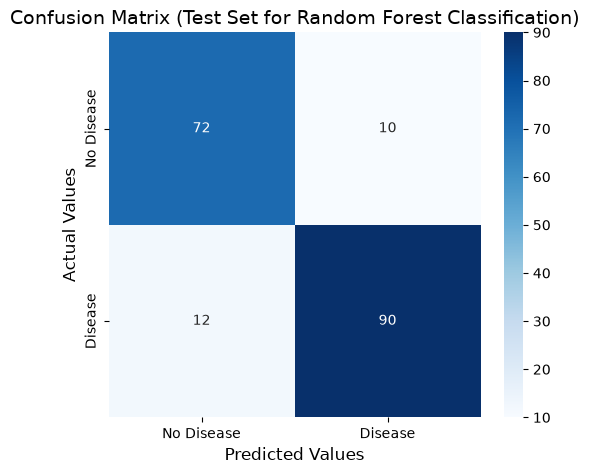

In [57]:
cm5=confusion_matrix(y_test,y_pred_test5)

plt.figure(figsize=(6, 5))
sns.heatmap(cm5,annot=True,fmt="d",cmap="Blues",
            xticklabels=["No Disease","Disease"],yticklabels=["No Disease","Disease"])
plt.title("Confusion Matrix (Test Set for Random Forest Classification)", fontsize=14)
plt.xlabel("Predicted Values", fontsize=12)
plt.ylabel("Actual Values", fontsize=12)
plt.show()

<i>Accuracy of the model</i>

In [58]:
print(f"Accuracy for the training set is: {accuracy_score(y_train,y_pred_train5)*100:.2f}%")

print(f"Accuracy for the test set is: {accuracy_score(y_test,y_pred_test5)*100:.2f}%")

Accuracy for the training set is: 100.00%
Accuracy for the test set is: 88.04%


<i>Feature importance</i>

- Checked which features the Random Forest relied on most

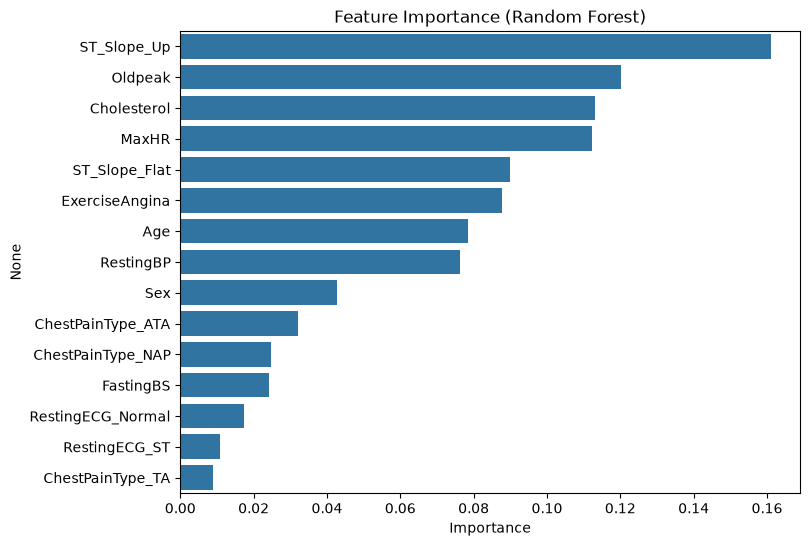

In [59]:
importances=pd.Series(classifier5.feature_importances_,index=feature_names).sort_values(ascending=False)

plt.figure(figsize=(8,6))
sns.barplot(x=importances.values,y=importances.index)
plt.title("Feature Importance (Random Forest)")
plt.xlabel("Importance")
plt.show()

<i>Error in the model</i>

In [60]:
print("Classification Report:")
print(classification_report(y_test,y_pred_test5,target_names=["No Disease","Disease"]))

Classification Report:
              precision    recall  f1-score   support

  No Disease       0.86      0.88      0.87        82
     Disease       0.90      0.88      0.89       102

    accuracy                           0.88       184
   macro avg       0.88      0.88      0.88       184
weighted avg       0.88      0.88      0.88       184



<i>Cross-Validation</i>

In [61]:
cv5=cross_val_score(classifier5,X_train,y_train,cv=10)

print(f"Training accuracy after cross-validation is: {cv5.mean()*100:.2f}%")

Training accuracy after cross-validation is: 87.60%


3.<u>Result</u>

- Model Performance Comparison

In [62]:
from sklearn.metrics import roc_auc_score

results={
    "Model":["Logistic Regression","K-Nearest Neighbors","Support Vector Classification",
             "Decision Tree Classification","Random Forest Classification"],
    "Training Accuracy (%)":[
        accuracy_score(y_train,y_pred_train)*100,
        accuracy_score(y_train,y_pred_train2)*100,
        accuracy_score(y_train,y_pred_train3)*100,
        accuracy_score(y_train,y_pred_train4)*100,
        accuracy_score(y_train,y_pred_train5)*100],
    "Testing Accuracy (%)":[
        accuracy_score(y_test,y_pred_test)*100,
        accuracy_score(y_test,y_pred_test2)*100,
        accuracy_score(y_test,y_pred_test3)*100,
        accuracy_score(y_test,y_pred_test4)*100,
        accuracy_score(y_test,y_pred_test5)*100],
    "F1-Score (Test)":[
        f1_score(y_test,y_pred_test),
        f1_score(y_test,y_pred_test2),
        f1_score(y_test,y_pred_test3),
        f1_score(y_test,y_pred_test4),
        f1_score(y_test,y_pred_test5)],
    "CV_Train (%)":[cv.mean()*100,np.mean(fold_scores)*100,cv3.mean()*100,cv4.mean()*100,cv5.mean()*100]
}

results_df=pd.DataFrame(results)
results_df

,Model,Training Accuracy (%),Testing Accuracy (%),F1-Score (Test),CV_Train (%)
0,Logistic Regression,87.057221,86.413043,0.874372,86.106997
1,K-Nearest Neighbors,91.689373,86.413043,0.870466,86.384672
2,Support Vector Classification,91.280654,88.043478,0.891089,86.780822
3,Decision Tree Classification,88.147139,85.326087,0.862944,83.235839
4,Random Forest Classification,100.000000,88.043478,0.891089,87.600889


4.<u>Model deployment</u>

- Deploying the best-performing classifier for future use

In [63]:
import pickle as pk

with open(r"scaler.pk","wb") as file:
    pk.dump(scaler,file)
    
with open(r"Random_Forest_Classifier.pk","wb") as file:
    pk.dump(classifier5,file)